### 1. 必要なデータの読み込み
・*Features.json*から特徴量(入力変数)を読み込んでいる<br>
・*user_ratings*として飲食店に対する評価(目的変数)を読み込んでいる<br>
・feature_namesは決定木のプロットで用いる特徴量の名前

In [447]:
import numpy as np
import json

user_ratings = [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0]
user_ratings_add = [1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0]

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

with open('Restaurants/AddFeatures.json', 'r', encoding='utf-8') as f:
    addFeatures = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user_ratings_np = np.array(user_ratings)
addFeatures_np = np.array(addFeatures)
user_ratings_add_np = np.array(user_ratings_add)

### 5フォールド交差検証


In [476]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import japanize_matplotlib

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'


# KFoldインスタンスを初期化
kf = KFold(n_splits=5, shuffle=True, random_state=2)

# 各フォールドの正解率を格納するリスト
accuracies = []

# 適合率を格納するリスト
precisions = []
positive_class_ratios = []

# フォールド番号を1から始めるためのカウンター
fold_counter = 1

# KFoldで分割されたインデックスを使ってループ
for train_index, test_index in kf.split(features):
    # トレーニングとテストセットを作成します。
    X_train, X_test = features_np[train_index], features_np[test_index]
    y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

    # 決定木の分類器を作成し、トレーニングデータにフィット
    classifier = DecisionTreeClassifier(random_state=0)
    classifier.fit(X_train, y_train)

    # テストデータに対する予測
    predictions = classifier.predict(X_test)

    # 正解率を計算し、リストに追加
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

    # 適合率を計算し、リストに追加
    precision = precision_score(y_test, predictions)
    precisions.append(precision)
    
    # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
    positive_class_ratio = np.mean(y_test)
    positive_class_ratios.append(positive_class_ratio)

    # 決定木のプロット
    """plt.figure(figsize=(20,10))
    plot_tree(classifier, filled=True, feature_names=feature_names)
    plt.title(f'Decision Tree for Fold {fold_counter}')
    plt.show()"""

    # 正しく予測できなかったインスタンスを出力
    """incorrect_indices = np.where(predictions != y_test)[0]
    print(f'Fold {fold_counter}')
    for index in incorrect_indices:
       # 出力
        print(f'Feature: {array_to_list_string(X_test[index])}')
        print(f'True Label: {y_test[index]}')
        print(f'Predicted Label: {predictions[index]}')
        print("---")"""

    # フォールドの正解率を出力
    print(f'Fold {fold_counter}: Accuracy = {accuracy}')
    
    # 次のフォールドへのカウンターを増やす
    fold_counter += 1

# 全フォールドでの平均正解率を出力
mean_accuracy = np.mean(accuracies)
print(f'\nMean Accuracy across all folds: {mean_accuracy}')

Fold 1: Accuracy = 0.65
Fold 2: Accuracy = 0.75
Fold 3: Accuracy = 0.55
Fold 4: Accuracy = 0.85
Fold 5: Accuracy = 0.8

Mean Accuracy across all folds: 0.72


### 10フォールド交差検証

In [485]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import japanize_matplotlib

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'


# KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 各フォールドの正解率を格納するリスト
accuracies = []

# 適合率を格納するリスト
precisions = []
positive_class_ratios = []

# フォールド番号を1から始めるためのカウンター
fold_counter = 1

# KFoldで分割されたインデックスを使ってループ
for train_index, test_index in kf.split(features):
    # トレーニングとテストセットを作成します。
    X_train, X_test = features_np[train_index], features_np[test_index]
    y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

    # 決定木の分類器を作成し、トレーニングデータにフィット
    classifier = DecisionTreeClassifier(random_state=0)
    classifier.fit(X_train, y_train)

    # テストデータに対する予測
    predictions = classifier.predict(X_test)

    # 正解率を計算し、リストに追加
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

    # 適合率を計算し、リストに追加
    precision = precision_score(y_test, predictions)
    precisions.append(precision)
    
    # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
    positive_class_ratio = np.mean(y_test)
    positive_class_ratios.append(positive_class_ratio)

    # 決定木のプロット
    """plt.figure(figsize=(20,10))
    plot_tree(classifier, filled=True, feature_names=feature_names)
    plt.title(f'Decision Tree for Fold {fold_counter}')
    plt.show()"""

    # 正しく予測できなかったインスタンスを出力
    """incorrect_indices = np.where(predictions != y_test)[0]
    print(f'Fold {fold_counter}')
    for index in incorrect_indices:
       # 出力
        print(f'Feature: {array_to_list_string(X_test[index])}')
        print(f'True Label: {y_test[index]}')
        print(f'Predicted Label: {predictions[index]}')
        print("---")"""

    # フォールドの正解率を出力
    print(f'Fold {fold_counter}: Accuracy = {accuracy}')
    
    # 次のフォールドへのカウンターを増やす
    fold_counter += 1

# 全フォールドでの平均正解率を出力
mean_accuracy = np.mean(accuracies)
print(f'\nMean Accuracy across all folds: {mean_accuracy}')

Fold 1: Accuracy = 0.8
Fold 2: Accuracy = 0.6
Fold 3: Accuracy = 0.4
Fold 4: Accuracy = 0.8
Fold 5: Accuracy = 0.9
Fold 6: Accuracy = 0.9
Fold 7: Accuracy = 0.5
Fold 8: Accuracy = 0.9
Fold 9: Accuracy = 0.5
Fold 10: Accuracy = 0.7

Mean Accuracy across all folds: 0.7000000000000001


### 検定
・交差検証の結果を使って, 検定を行った.

In [491]:
from scipy import stats

# 決定木モデルの平均適合率
mean_precision_tree = np.mean(precisions)
print(precisions)
# ランダム手法の平均適合率の計算
mean_precision_random = np.mean([positive_class_ratios])
print(positive_class_ratios)

# 検定の実施
w_stat, p_value = stats.wilcoxon(precisions, positive_class_ratios)

print(f"決定木モデルの平均適合率: {mean_precision_tree}")
print(f"ランダム手法の平均適合率: {mean_precision_random}")
print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

[0.8333333333333334, 0.5, 0.6, 0.5, 1.0, 1.0, 0.2, 0.75, 1.0, 0.5]
[0.6, 0.4, 0.7, 0.2, 0.3, 0.5, 0.2, 0.3, 0.9, 0.3]
決定木モデルの平均適合率: 0.6883333333333334
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 2.0, p値 = 0.014801612180980936


In [492]:
from scipy import stats

# 決定木モデルの平均適合率
mean_accuracy_tree = np.mean(accuracies)
print(accuracies)
# ランダム手法の平均適合率の計算
accuracy_random = [0.5] * 10
mean_accuracy_random = np.mean(accuracy_random)
print(accuracy_random)

# 検定の実施
w_stat, p_value = stats.wilcoxon(accuracies, accuracy_random)

print(f"決定木モデルの平均正解率: {mean_accuracy_tree}")
print(f"ランダム手法の平均正解率: {mean_accuracy_random}")
print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

[0.8, 0.6, 0.4, 0.8, 0.9, 0.9, 0.5, 0.9, 0.5, 0.7]
[0.6, 0.4, 0.7, 0.2, 0.3, 0.5, 0.2, 0.3, 0.9, 0.3]
決定木モデルの平均正解率: 0.7000000000000001
ランダム手法の平均正解率: 0.5
検定結果: 統計量 = 1.5, p値 = 0.019931199293565356


/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


In [462]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold

# モデルの初期化
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "SVM": SVC(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=500),
    "k-NN": KNeighborsClassifier()
}

# KFoldインスタンスを初期化
kf = KFold(n_splits=5, shuffle=True, random_state=2)

# 結果を格納するための辞書
results = {name: {"Accuracy": [], "Precision": [], "Recall": [], "F1": []} for name in models.keys()}

# 各モデルに対して交差検証を行う
for name, model in models.items():
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # モデルを訓練
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        results[name]["Accuracy"].append(accuracy)
        results[name]["Precision"].append(precision)
        results[name]["Recall"].append(recall)
        results[name]["F1"].append(f1)

# 結果の表示
for name, scores in results.items():
    mean_accuracy = np.mean(scores["Accuracy"])
    mean_precision = np.mean(scores["Precision"])
    mean_recall = np.mean(scores["Recall"])
    mean_f1 = np.mean(scores["F1"])
    print(name)
    print(f"Mean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")


Decision Tree
Mean Accuracy: 0.72, Mean Precision: 0.6694139194139195, Mean Recall: 0.71, Mean_F1: 0.682992327365729

SVM
Mean Accuracy: 0.67, Mean Precision: 0.627070707070707, Mean Recall: 0.65, Mean_F1: 0.6211764705882352

Logistic Regression
Mean Accuracy: 0.6700000000000002, Mean Precision: 0.6611111111111111, Mean Recall: 0.5800000000000001, Mean_F1: 0.5978057889822596

k-NN
Mean Accuracy: 0.6199999999999999, Mean Precision: 0.5681818181818181, Mean Recall: 0.55, Mean_F1: 0.5347744360902256



### 3. テスト


Training size: 20
Accuracy: 0.55
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.36      0.67      0.47         6

    accuracy                           0.55        20
   macro avg       0.57      0.58      0.54        20
weighted avg       0.65      0.55      0.57        20


Training size: 40
Accuracy: 0.55
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.50      0.61        14
           1       0.36      0.67      0.47         6

    accuracy                           0.55        20
   macro avg       0.57      0.58      0.54        20
weighted avg       0.65      0.55      0.57        20


Training size: 60
Accuracy: 0.7
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        14
           1       0.50      0.50      0.50         6

    accuracy

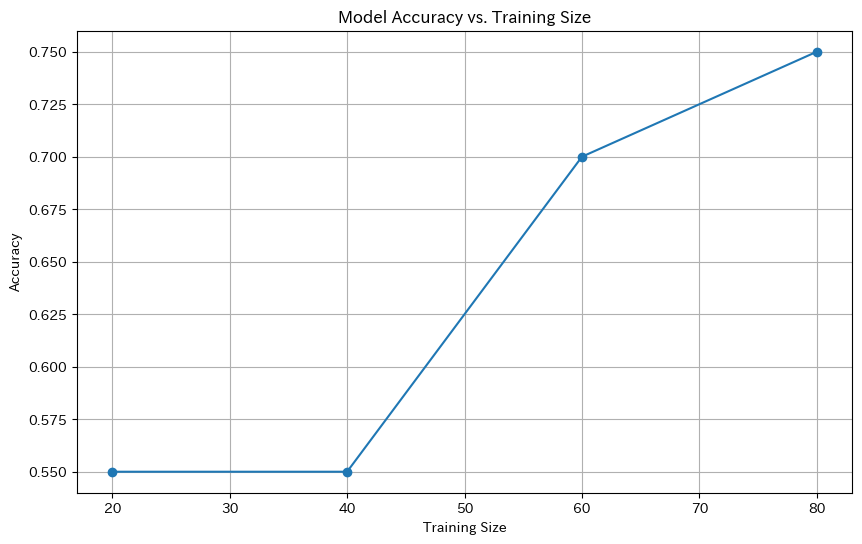

In [430]:
import random
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# ランダムにテストデータを選択する関数
def random_split(features, user_ratings, test_size=20):
    paired_data = list(zip(features, user_ratings))
    random.seed(41)
    random.shuffle(paired_data)
    
    test_data = paired_data[:test_size]
    train_data = paired_data[test_size:]
    
    test_features, test_labels = zip(*test_data)
    train_features, train_labels = zip(*train_data)
    
    return list(train_features), list(train_labels), list(test_features), list(test_labels)

# features と user_ratings が既に定義されていると仮定
train_features, train_labels, test_features, test_labels = random_split(features, user_ratings, 20)

train_sizes = [20, 40, 60, 80]
accuracies = []

for size in train_sizes:
    # 訓練データのサイズに基づいてモデルを訓練
    clf = DecisionTreeClassifier(random_state=0)
    clf.fit(train_features[:size], train_labels[:size])
    
    # テストデータで精度を計算
    predictions = clf.predict(test_features)
    accuracy = accuracy_score(test_labels, predictions)
    accuracies.append(accuracy)

    # 分類レポートの表示
    print(f"\nTraining size: {size}")
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(classification_report(test_labels, predictions))

# 結果のプロット
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, accuracies, marker='o')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs. Training Size')
plt.grid(True)
plt.show()
